

What you get:
1) Load + clean the dataset
2) EDA and diagnostics (trend/seasonality, ADF test, ACF/PACF)
3) Time-based train/test split
4) Baseline forecasts (naive, mean, drift, seasonal naive)
5) Statistical models (SES, Holt, Holt-Winters, ARIMA)
6) Supervised ML model with engineered features (RandomForest)
7) Compare metrics and export forecasts

Notes:
- The data is 15-minute resolution. Keep that frequency for fine-grained
  forecasts or resample to hourly/daily for faster training.
- The default target column is "MeasuredProduction". Change TARGET_COL if needed.

## Imports and configuration


In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")


@dataclass
class Config:
    # File paths (deprecated in favor of dbt pipeline)
    # data_path: Path = Path("final/albuquerque_116_data1293_model_advanced_energy_solaron.csv")
    output_dir: Path = Path("final/outputs")

    # Column names
    time_col: str = "time"
    target_col: str = "target_ac_power"
    device_col: str = "id_device"

    # Frequency handling
    base_freq: str = "15min"     # native data frequency
    resample_rule: str | None = None  # e.g., "H", "D" or None to keep base_freq

    # Train/test split
    test_days: int = 90  # last N days for test

    # Seasonality
    seasonal_periods: int | None = None  # computed automatically when None

    # Feature engineering
    lags: tuple[int, ...] = (1, 2, 4, 8, 96, 192, 672)  # 15-min: 96/day, 672/week
    rolling_windows: tuple[int, ...] = (4, 12, 96)      # 1h, 3h, 1d in 15-min steps

    # ARIMA search space (keep small for speed)
    arima_p: tuple[int, ...] = (0, 1, 2)
    arima_d: tuple[int, ...] = (0, 1)
    arima_q: tuple[int, ...] = (0, 1, 2)
    arima_train_window: int | None = 5000  # optional cap for ARIMA training


CFG = Config()
CFG.output_dir.mkdir(parents=True, exist_ok=True)


## Utility helpers


In [2]:
def infer_seasonal_periods(freq: str) -> int:
    """
    Infer common seasonality by frequency.
    Adjust if your data shows a different cycle.
    """
    freq = freq.lower()
    if freq in ("15min", "15t", "15min"):
        return 96  # 96 x 15-min = 1 day
    if freq in ("h", "1h", "hourly"):
        return 24
    if freq in ("d", "1d", "daily"):
        return 7
    return 1


def periods_from_days(days: int, freq: str) -> int:
    """Convert a day-based horizon to number of periods for the given frequency."""
    freq = freq.lower()
    if freq in ("15min", "15t", "15min"):
        return days * 24 * 4
    if freq in ("h", "1h", "hourly"):
        return days * 24
    if freq in ("d", "1d", "daily"):
        return days
    raise ValueError(f"Unsupported frequency for conversion: {freq}")


def print_header(title: str) -> None:
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


## Step 1: Load and clean data


In [3]:
def load_data(cfg: Config) -> pd.DataFrame:
    """
    Load CSV, parse timestamps, ensure numeric types, and enforce a time index.
    """

    con = duckdb.connect("../db/energy.duckdb")
    try:
        print_header("STEP 1 - LOAD DATA")
        df = con.execute("""
            select *
            from main_mart.mart_training_energy
            order by id_device, ts
            """).df()
    finally:
        con.close()
    print(f"Raw shape: {df.shape}")

    time_col = cfg.time_col
    if time_col not in df.columns:
        candidates = [
            col
            for col in df.columns
            if col.lower() in ("ts", "timestamp", "datetime", "date", "time")
        ]
        if not candidates:
            datetime_cols = [
                col for col in df.columns if pd.api.types.is_datetime64_any_dtype(df[col])
            ]
            candidates = datetime_cols
        time_col = candidates[0] if candidates else None

    if time_col is None:
        raise ValueError("No timestamp column found. Set CFG.time_col to a valid column.")

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col]).sort_values(time_col)
    df = df.set_index(time_col)

    if cfg.resample_rule:
        df = df.resample(cfg.resample_rule).mean()

    print(f"Clean shape: {df.shape}")
    print(f"Time range: {df.index.min()} -> {df.index.max()}")

    return df


df_clean = load_data(CFG)
#df_clean = clean_missing(df_raw, CFG)

base_freq = (CFG.resample_rule or CFG.base_freq).lower()
if isinstance(df_clean.index, pd.DatetimeIndex):
    inferred = pd.infer_freq(df_clean.index)
    if inferred is not None:
        inferred = inferred.lower()
        if inferred in ("15t", "15min", "h", "1h", "d", "1d", "hourly", "daily"):
            base_freq = inferred

seasonal_periods = CFG.seasonal_periods or infer_seasonal_periods(base_freq)



STEP 1 - LOAD DATA
Raw shape: (346426, 10)
Clean shape: (346426, 9)
Time range: 2020-06-01 18:45:00 -> 2025-12-16 03:40:00


## Step 2: Quick EDA + diagnostics



STEP 3 - BASIC EDA
count    346426.000000
mean         88.606948
std         127.753580
min          -3.000000
25%           0.000000
50%           0.000000
75%         179.000000
max         503.600000
Name: target_ac_power, dtype: float64


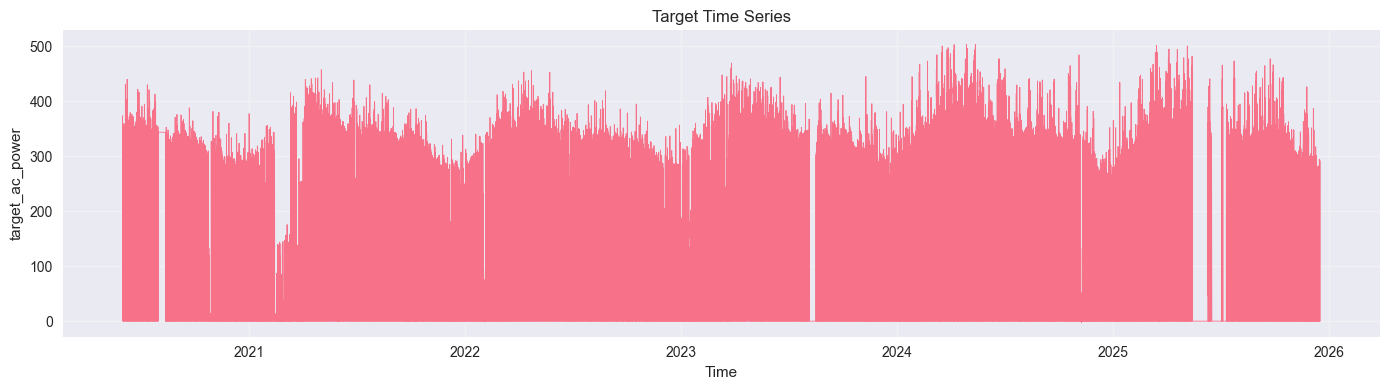

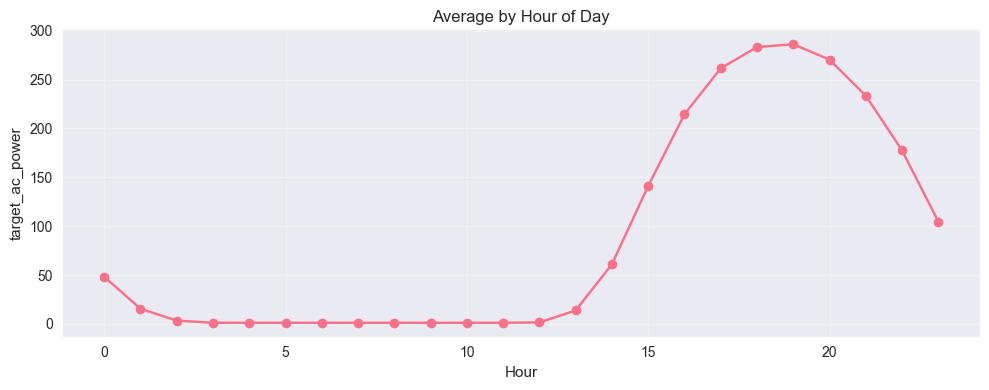


STEP 4 - STATIONARITY (ADF)
ADF Statistic: -58.4602
ADF p-value : 0.0000
Conclusion: Likely stationary

STEP 5 - SEASONAL DECOMPOSITION


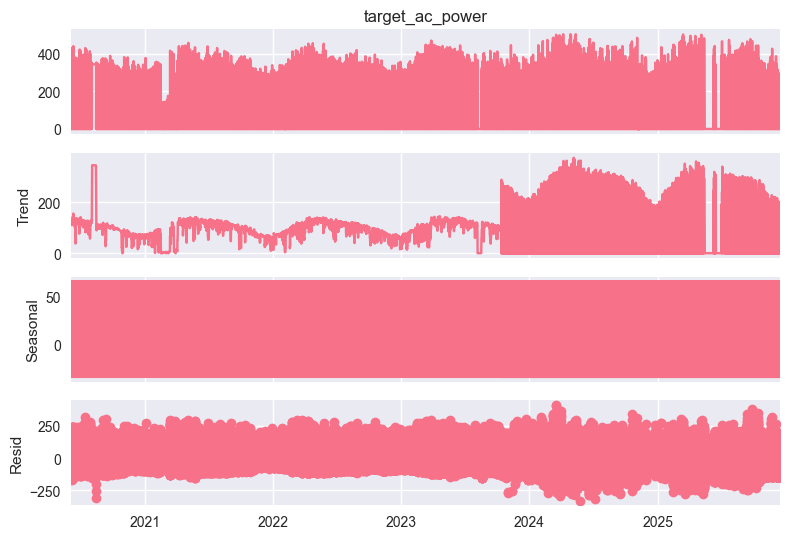


STEP 6 - ACF / PACF


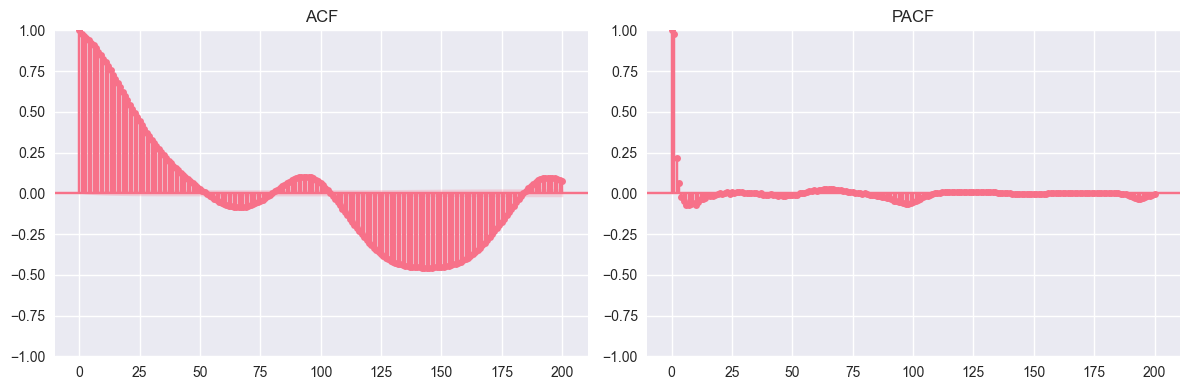

In [ ]:
def basic_eda(df: pd.DataFrame, cfg: Config) -> None:
    """
    Basic stats and a few quick plots to understand the target behavior.
    """
    print_header("STEP 3 - BASIC EDA")
    print(df[cfg.target_col].describe())

    # Plot the full series (may be dense; adjust if needed)
    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(df.index, df[cfg.target_col], linewidth=0.6)
    ax.set_title("Target Time Series")
    ax.set_xlabel("Time")
    ax.set_ylabel(cfg.target_col)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Daily average profile (useful for 15-min data)
    idx = df.index
    is_dt_index = isinstance(idx, pd.DatetimeIndex)
    idx_freq = idx.freq if is_dt_index else None
    if idx_freq is not None or cfg.base_freq == "15min":
        hour_values = None
        if is_dt_index:
            hour_values = idx.hour
        elif cfg.time_col in df.columns:
            hour_values = pd.to_datetime(df[cfg.time_col], errors="coerce").dt.hour

        if hour_values is not None:
            daily_profile = df[cfg.target_col].groupby(hour_values).mean()
            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            ax.plot(daily_profile.index, daily_profile.values, marker="o")
            ax.set_title("Average by Hour of Day")
            ax.set_xlabel("Hour")
            ax.set_ylabel(cfg.target_col)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("Skipping hourly profile: no datetime index or time column available.")
def stationarity_tests(series: pd.Series) -> None:
    """
    Run Augmented Dickey-Fuller test for stationarity.
    """
    print_header("STEP 4 - STATIONARITY (ADF)")
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"ADF p-value : {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Conclusion: Likely stationary")
    else:
        print("Conclusion: Likely non-stationary (consider differencing)")


def decomposition_plot(series: pd.Series, period: int) -> None:
    """
    Seasonal decomposition to visualize trend/seasonal/residual components.
    """
    print_header("STEP 5 - SEASONAL DECOMPOSITION")
    decomposition = seasonal_decompose(series, model="additive", period=period)
    decomposition.plot()
    plt.tight_layout()
    plt.show()


def acf_pacf_plot(series: pd.Series, lags: int) -> None:
    """
    ACF/PACF to inspect autocorrelation.
    """
    print_header("STEP 6 - ACF / PACF")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    plot_pacf(series.dropna(), lags=lags, ax=axes[1])
    axes[0].set_title("ACF")
    axes[1].set_title("PACF")
    plt.tight_layout()
    plt.show()

# Diagnostics execution
basic_eda(df_clean, CFG)
stationarity_tests(df_clean[CFG.target_col])
decomposition_plot(df_clean[CFG.target_col], period=seasonal_periods)
acf_pacf_plot(df_clean[CFG.target_col], lags=min(200, len(df_clean) // 10))



## Step 3: Train/test split



STEP 7 - TRAIN/TEST SPLIT
Train size: 337786
Test size : 8640
Train range: 2020-06-01 18:45:00 -> 2025-11-16 02:40:00
Test range : 2025-11-16 02:45:00 -> 2025-12-16 03:40:00


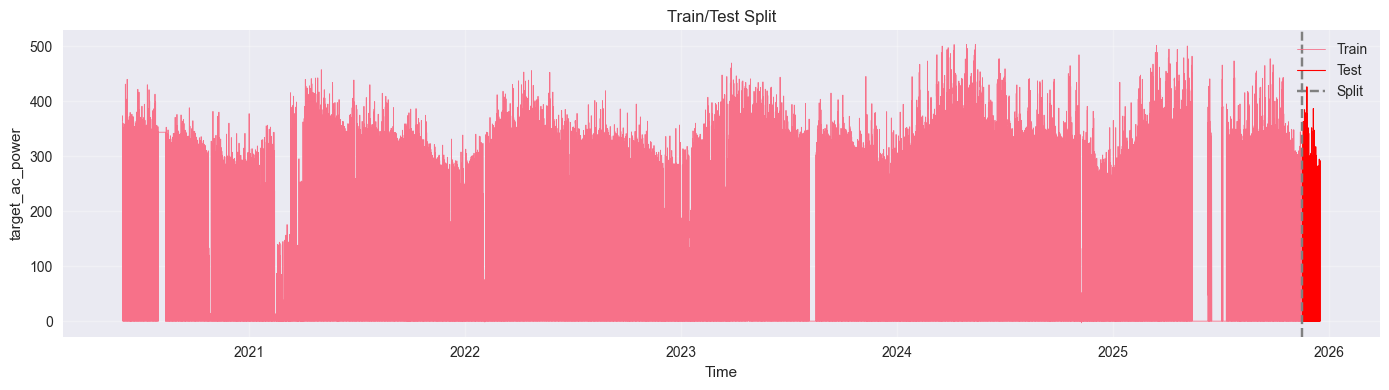

In [5]:
def train_test_split_time(series: pd.Series, cfg: Config, freq: str) -> tuple[pd.Series, pd.Series]:
    """
    Split using the last N days as test.
    """
    print_header("STEP 7 - TRAIN/TEST SPLIT")
    test_size = periods_from_days(cfg.test_days, freq)
    train = series.iloc[:-test_size]
    test = series.iloc[-test_size:]

    print(f"Train size: {len(train)}")
    print(f"Test size : {len(test)}")
    print(f"Train range: {train.index.min()} -> {train.index.max()}")
    print(f"Test range : {test.index.min()} -> {test.index.max()}")

    # Visualize the split
    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(train.index, train.values, label="Train", linewidth=0.6)
    ax.plot(test.index, test.values, label="Test", linewidth=0.8, color="red")
    ax.axvline(x=train.index[-1], color="gray", linestyle="--", label="Split")
    ax.set_title("Train/Test Split")
    ax.set_xlabel("Time")
    ax.set_ylabel(cfg.target_col)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return train, test

# Train/test
train_series, test_series = train_test_split_time(
    df_clean[CFG.target_col], CFG, base_freq
)

  

## Step 4: Metrics


In [6]:
def mase(y_true: np.ndarray, y_pred: np.ndarray, y_train: np.ndarray) -> float:
    """
    Mean Absolute Scaled Error (MASE) using naive one-step forecast on training data.
    """
    naive = np.abs(np.diff(y_train))
    denom = np.mean(naive) if len(naive) > 0 else np.nan
    return np.mean(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan


def evaluate_forecast(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_train: pd.Series,
    name: str,
) -> dict:
    """
    Compute MAE, RMSE, MAPE, and MASE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mase_val = mase(y_true.values, y_pred, y_train.values)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "MASE": mase_val,
    }


## Step 5: Baseline models


In [7]:
def baseline_forecasts(train: pd.Series, horizon: int, seasonal_periods: int) -> dict:
    """
    Naive, mean, drift, and seasonal naive baselines.
    """
    last_value = train.iloc[-1]
    mean_value = train.mean()
    drift = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)

    # Seasonal naive uses the last observed season
    last_season = train.iloc[-seasonal_periods:].values
    seasonal_naive = np.tile(last_season, int(np.ceil(horizon / seasonal_periods)))[:horizon]

    forecasts = {
        "Naive": np.repeat(last_value, horizon),
        "Mean": np.repeat(mean_value, horizon),
        "Drift": np.array([last_value + drift * (i + 1) for i in range(horizon)]),
        "SeasonalNaive": seasonal_naive,
    }
    return forecasts


## Step 6: Statistical models 

In [8]:
def fit_ses(train: pd.Series, horizon: int) -> np.ndarray:
    model = SimpleExpSmoothing(train).fit(optimized=True)
    return model.forecast(horizon).values


def fit_holt(train: pd.Series, horizon: int) -> np.ndarray:
    model = Holt(train).fit(optimized=True)
    return model.forecast(horizon).values


def fit_holt_winters(train: pd.Series, horizon: int, seasonal_periods: int) -> np.ndarray:
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=seasonal_periods,
    ).fit(optimized=True)
    return model.forecast(horizon).values


def find_best_arima_order(train: pd.Series, cfg: Config) -> tuple[int, int, int]:
    """
    Small ARIMA grid search by AIC (demo_2 style).
    """
    best_aic = np.inf
    best_order = (0, 0, 0)

    for p in cfg.arima_p:
        for d in cfg.arima_d:
            for q in cfg.arima_q:
                try:
                    model = ARIMA(train, order=(p, d, q))
                    fitted = model.fit()
                    if fitted.aic < best_aic:
                        best_aic = fitted.aic
                        best_order = (p, d, q)
                except Exception:
                    continue

    print(f"Best ARIMA order: {best_order} (AIC={best_aic:.2f})")
    return best_order


def fit_arima(train: pd.Series, horizon: int, cfg: Config) -> np.ndarray:
    """
    ARIMA model with optional training window to reduce cost.
    """
    if cfg.arima_train_window and len(train) > cfg.arima_train_window:
        train = train.iloc[-cfg.arima_train_window:]

    order = find_best_arima_order(train, cfg)
    model = ARIMA(train, order=order).fit()
    return model.forecast(horizon).values


def fit_prophet(train: pd.Series, horizon: int, freq: str) -> np.ndarray | None:
    """
    Optional Prophet model. Install with: pip install prophet
    """
    try:
        from prophet import Prophet
    except Exception:
        print("Prophet not installed; skipping.")
        return None

    df_prophet = pd.DataFrame({"ds": train.index, "y": train.values})
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="additive",
    )
    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=horizon, freq=freq)
    forecast = model.predict(future)
    return forecast["yhat"].iloc[-horizon:].values


## Step 7: Feature engineering + ML model 


In [9]:
def make_time_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Generate datetime-based features.
    """
    df = pd.DataFrame(index=index)
    df["hour"] = index.hour
    df["dayofweek"] = index.dayofweek
    df["month"] = index.month
    df["dayofyear"] = index.dayofyear

    # Cyclical encoding for periodicity
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    return df


def select_exogenous_features(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Select numeric exogenous features while avoiding obvious leakage.
    Adjust this list based on domain knowledge.
    """
    drop = {
        cfg.target_col,
        cfg.device_col,
        "timestamp_15minutes",
        "current_time",
        "year",
        "month",
        "day",
        "hour",
        "minutes",
        "seconds",
    }

    # Remove cumulative totals that can leak future information
    for col in df.columns:
        lower = col.lower()
        if "total" in lower or lower.startswith("ytd") or lower.startswith("life"):
            drop.add(col)

    return df.drop(columns=[c for c in drop if c in df.columns])


def make_lag_features(series: pd.Series, lags: tuple[int, ...]) -> pd.DataFrame:
    df = pd.DataFrame(index=series.index)
    for lag in lags:
        df[f"lag_{lag}"] = series.shift(lag)
    return df


def make_rolling_features(series: pd.Series, windows: tuple[int, ...]) -> pd.DataFrame:
    df = pd.DataFrame(index=series.index)
    for window in windows:
        df[f"roll_mean_{window}"] = series.rolling(window).mean()
        df[f"roll_min_{window}"] = series.rolling(window).min()
        df[f"roll_max_{window}"] = series.rolling(window).max()
    return df


def build_supervised_dataset(df: pd.DataFrame, cfg: Config) -> tuple[pd.DataFrame, pd.Series]:
    """
    Combine time features, exogenous variables, lags, and rolling stats.
    """
    y = df[cfg.target_col]

    features = make_time_features(df.index)
    features = features.join(select_exogenous_features(df, cfg))
    features = features.join(make_lag_features(y, cfg.lags))
    features = features.join(make_rolling_features(y, cfg.rolling_windows))

    # Drop rows with NaNs created by lag/rolling features
    dataset = features.join(y).dropna()
    X = dataset.drop(columns=[cfg.target_col])
    y = dataset[cfg.target_col]
    return X, y


def fit_random_forest(X_train: pd.DataFrame, y_train: pd.Series) -> RandomForestRegressor:
    """
    A simple supervised model for time series using engineered features.
    """
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    return model


## Step 8: Model comparison and plotting


In [ ]:
def compare_models(
    df_full: pd.DataFrame,
    train: pd.Series,
    test: pd.Series,
    freq: str,
    seasonal_periods: int,
    cfg: Config,
) -> pd.DataFrame:
    """
    Train multiple models and compare metrics.
    """
    print_header("STEP 8 - MODEL TRAINING AND EVALUATION")
    horizon = len(test)

    results = []
    forecasts = {}

    # Baselines
    baseline = baseline_forecasts(train, horizon, seasonal_periods)
    for name, pred in baseline.items():
        forecasts[name] = pred
        results.append(evaluate_forecast(test, pred, train, name))

    # Exponential smoothing models
    forecasts["SES"] = fit_ses(train, horizon)
    forecasts["Holt"] = fit_holt(train, horizon)
    forecasts["HoltWinters"] = fit_holt_winters(train, horizon, seasonal_periods)

    for name in ["SES", "Holt", "HoltWinters"]:
        results.append(evaluate_forecast(test, forecasts[name], train, name))

    # ARIMA (small search)
    forecasts["ARIMA"] = fit_arima(train, horizon, cfg)
    results.append(evaluate_forecast(test, forecasts["ARIMA"], train, "ARIMA"))

    # Prophet (optional)
    prophet_pred = fit_prophet(train, horizon, freq)
    if prophet_pred is not None:
        forecasts["Prophet"] = prophet_pred
        results.append(evaluate_forecast(test, forecasts["Prophet"], train, "Prophet"))

    # ML model with engineered features
    X, y = build_supervised_dataset(df_full, cfg)
    split_idx = len(y) - horizon
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    rf_model = fit_random_forest(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    forecasts["RandomForest"] = rf_pred
    results.append(evaluate_forecast(y_test, rf_pred, y_train, "RandomForest"))

    # Aggregate results
    df_results = pd.DataFrame(results).sort_values("MAE")
    print(df_results[["Model", "MAE", "RMSE", "MAPE", "MASE"]].to_string(index=False))

    # Plot forecasts for top models
    top_models = df_results["Model"].head(5).tolist()
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    ax.plot(train.index, train.values, label="Train", linewidth=0.6)
    ax.plot(test.index, test.values, label="Test", linewidth=1.0, color="black")
    for name in top_models:
        pred = forecasts[name]
        ax.plot(test.index, pred, "--", linewidth=1.4, label=name)
    ax.set_title("Top Model Forecasts vs Actual")
    ax.set_xlabel("Time")
    ax.set_ylabel(CFG.target_col)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save forecasts
    out = pd.DataFrame({"actual": test.values}, index=test.index)
    for name, pred in forecasts.items():
        if len(pred) == len(test):
            out[name] = pred
    out_path = CFG.output_dir / "forecast_comparison.csv"
    out.to_csv(out_path)
    print(f"Saved forecasts: {out_path}")

    return df_results

###COMPARE MODELS###
if "train_series" not in globals() or "test_series" not in globals():
    train_series, test_series = train_test_split_time(
        df_clean[CFG.target_col], CFG, base_freq
    )
results = compare_models(
    df_full=df_clean,
    train=train_series,
    test=test_series,
    freq=base_freq,
    seasonal_periods=seasonal_periods,
    cfg=CFG,
)


STEP 8 - MODEL TRAINING AND EVALUATION
Best ARIMA order: (2, 1, 2) (AIC=39987.20)


## Save outputs


In [ ]:
# Save metrics
metrics_path = CFG.output_dir / "model_metrics.csv"
results.to_csv(metrics_path, index=False)
print(f"Saved metrics: {metrics_path}")


Saved metrics: final\outputs\model_metrics.csv
